# 02 · 斑块进展预测 · 模型训练与评估

## 流程
1. 加载 `processed/A_baseline/` 数据(已填补 + 标准化)
2. 还原患者分组(用于 GroupKFold)
3. **基线**:Logistic Regression (L2 / L1) + Random Forest,均启用 `class_weight='balanced'`
4. **主力**:XGBoost / LightGBM,Optuna 50 trials × GroupKFold(5),目标 = 平均 AUPRC
5. 用 Train+Val 上以最优超参重训,在测试集上**一次性评估**
6. Bootstrap 1000 次给 AUROC / AUPRC 的 95% CI
7. 验证集上选最优阈值(Youden's J),报敏感度/特异度/PPV/NPV/F1
8. 保存模型 + 指标表 + ROC/PR 曲线

In [1]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, brier_score_loss,
                             f1_score, matthews_corrcoef)
import xgboost as xgb
import lightgbm as lgb
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
RNG = 42
DATA_DIR = 'processed/A_baseline'
OUT_DIR  = 'results';  os.makedirs(OUT_DIR, exist_ok=True)
MODEL_DIR = 'models';  os.makedirs(MODEL_DIR, exist_ok=True)
print('OK')

OK


## 1. 加载数据 + 还原 patient groups

In [2]:
X_train = pd.read_parquet(f'{DATA_DIR}/X_train.parquet')
X_val   = pd.read_parquet(f'{DATA_DIR}/X_val.parquet')
X_test  = pd.read_parquet(f'{DATA_DIR}/X_test.parquet')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_val   = np.load(f'{DATA_DIR}/y_val.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

split_meta = pd.read_csv('processed/split_meta.csv').set_index('row_index')
groups_train = split_meta.loc[X_train.index, 'accession_id'].values
groups_val   = split_meta.loc[X_val.index,   'accession_id'].values
groups_test  = split_meta.loc[X_test.index,  'accession_id'].values

X_trainval = pd.concat([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
groups_trainval = np.concatenate([groups_train, groups_val])

print(f'Train={X_train.shape}  Val={X_val.shape}  Test={X_test.shape}')
print(f'Patients  Train={len(set(groups_train))}  Val={len(set(groups_val))}  Test={len(set(groups_test))}')
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (train) = {spw:.3f}')

Train=(1395, 91)  Val=(364, 91)  Test=(449, 91)
Patients  Train=840  Val=211  Test=263
scale_pos_weight (train) = 5.228


## 2. 评估工具函数

In [3]:
def boot_ci(metric_fn, y_true, y_score, n_boot=1000, seed=RNG, alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(y_true); stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        stats.append(metric_fn(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(stats, [100*alpha/2, 100*(1-alpha/2)])
    return lo, hi

def best_threshold_youden(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    j = tpr - fpr
    return thr[int(np.argmax(j))]

def metrics_at_threshold(y_true, y_score, thr):
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    sens = tp / (tp+fn) if (tp+fn) else 0
    spec = tn / (tn+fp) if (tn+fp) else 0
    ppv  = tp / (tp+fp) if (tp+fp) else 0
    npv  = tn / (tn+fn) if (tn+fn) else 0
    return dict(threshold=thr, sensitivity=sens, specificity=spec,
                ppv=ppv, npv=npv, f1=f1_score(y_true, y_pred, zero_division=0),
                mcc=matthews_corrcoef(y_true, y_pred))

def evaluate(model_name, y_test_score, y_val_score):
    auroc = roc_auc_score(y_test, y_test_score)
    auprc = average_precision_score(y_test, y_test_score)
    auroc_ci = boot_ci(roc_auc_score, y_test, y_test_score)
    auprc_ci = boot_ci(average_precision_score, y_test, y_test_score)
    thr = best_threshold_youden(y_val, y_val_score)
    m = metrics_at_threshold(y_test, y_test_score, thr)
    brier = brier_score_loss(y_test, y_test_score)
    return dict(model=model_name, AUROC=auroc, AUROC_lo=auroc_ci[0], AUROC_hi=auroc_ci[1],
                AUPRC=auprc, AUPRC_lo=auprc_ci[0], AUPRC_hi=auprc_ci[1],
                Brier=brier, **m)

print('helpers ready')

helpers ready


## 3. 基线模型(无需调参)

In [4]:
def fit_predict(model, X_tr, y_tr, X_v, X_te):
    model.fit(X_tr, y_tr)
    p_v  = model.predict_proba(X_v)[:, 1]
    p_te = model.predict_proba(X_te)[:, 1]
    return model, p_v, p_te

results = []
models  = {}

lr_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000,
                           class_weight='balanced', random_state=RNG)
lr_l2, p_v, p_te = fit_predict(lr_l2, X_train, y_train, X_val, X_test)
results.append(evaluate('LogReg-L2', p_te, p_v))
models['LogReg-L2'] = lr_l2

lr_l1 = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', max_iter=2000,
                           class_weight='balanced', random_state=RNG)
lr_l1, p_v, p_te = fit_predict(lr_l1, X_train, y_train, X_val, X_test)
results.append(evaluate('LogReg-L1', p_te, p_v))
models['LogReg-L1'] = lr_l1
n_nonzero = int((np.abs(lr_l1.coef_) > 1e-8).sum())
print(f'LogReg-L1 保留特征数: {n_nonzero} / {X_train.shape[1]}')

rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=3,
                            max_features='sqrt', class_weight='balanced',
                            n_jobs=-1, random_state=RNG)
rf, p_v, p_te = fit_predict(rf, X_train, y_train, X_val, X_test)
results.append(evaluate('RandomForest', p_te, p_v))
models['RandomForest'] = rf

pd.DataFrame(results)[['model','AUROC','AUPRC','Brier','sensitivity','specificity','f1']]

LogReg-L1 保留特征数: 69 / 91


,model,AUROC,AUPRC,Brier,sensitivity,specificity,f1
0,LogReg-L2,0.630734,0.258044,0.216782,0.791045,0.366492,0.292818
1,LogReg-L1,0.632453,0.248981,0.217794,0.776119,0.424084,0.306785
2,RandomForest,0.692623,0.286347,0.122680,0.671642,0.602094,0.340909


## 4. XGBoost · Optuna 调参
GroupKFold(5) on Train, 目标 = mean AUPRC, 50 trials

In [5]:
GKF = GroupKFold(n_splits=5)

def cv_score_xgb(params):
    aps = []
    for tr, va in GKF.split(X_train, y_train, groups_train):
        Xt, Xv = X_train.iloc[tr], X_train.iloc[va]
        yt, yv = y_train[tr], y_train[va]
        spw_fold = (yt == 0).sum() / max((yt == 1).sum(), 1)
        m = xgb.XGBClassifier(**params, scale_pos_weight=spw_fold,
                              eval_metric='aucpr', tree_method='hist',
                              n_jobs=-1, random_state=RNG)
        m.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False)
        aps.append(average_precision_score(yv, m.predict_proba(Xv)[:, 1]))
    return float(np.mean(aps))

def objective_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        min_child_weight = trial.suggest_float('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
    )
    return cv_score_xgb(params)

study_xgb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RNG))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=False)
print('XGB best CV AUPRC:', round(study_xgb.best_value, 4))
print('XGB best params:', study_xgb.best_params)

XGB best CV AUPRC: 0.2754
XGB best params: {'n_estimators': 559, 'max_depth': 8, 'learning_rate': 0.01303561122512888, 'min_child_weight': 2.763845761772307, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.6626651653816322, 'gamma': 1.9433864484474102, 'reg_alpha': 2.293280024184598e-06, 'reg_lambda': 0.16186864586521713}


In [6]:
xgb_best = xgb.XGBClassifier(**study_xgb.best_params, scale_pos_weight=spw,
                             eval_metric='aucpr', tree_method='hist',
                             n_jobs=-1, random_state=RNG)
xgb_best, p_v, p_te = fit_predict(xgb_best, X_train, y_train, X_val, X_test)
results.append(evaluate('XGBoost', p_te, p_v))
models['XGBoost'] = xgb_best
pd.DataFrame(results)[['model','AUROC','AUPRC']]

,model,AUROC,AUPRC
0,LogReg-L2,0.630734,0.258044
1,LogReg-L1,0.632453,0.248981
2,RandomForest,0.692623,0.286347
3,XGBoost,0.671876,0.272089


## 5. LightGBM · Optuna 调参

In [7]:
def cv_score_lgb(params):
    aps = []
    for tr, va in GKF.split(X_train, y_train, groups_train):
        Xt, Xv = X_train.iloc[tr], X_train.iloc[va]
        yt, yv = y_train[tr], y_train[va]
        spw_fold = (yt == 0).sum() / max((yt == 1).sum(), 1)
        m = lgb.LGBMClassifier(**params, scale_pos_weight=spw_fold,
                               objective='binary', n_jobs=-1,
                               random_state=RNG, verbose=-1)
        m.fit(Xt, yt, eval_set=[(Xv, yv)])
        aps.append(average_precision_score(yv, m.predict_proba(Xv)[:, 1]))
    return float(np.mean(aps))

def objective_lgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        num_leaves       = trial.suggest_int('num_leaves', 15, 127),
        max_depth        = trial.suggest_int('max_depth', -1, 12),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 60),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
    )
    return cv_score_lgb(params)

study_lgb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RNG))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=False)
print('LGB best CV AUPRC:', round(study_lgb.best_value, 4))
print('LGB best params:', study_lgb.best_params)

LGB best CV AUPRC: 0.2534
LGB best params: {'n_estimators': 796, 'num_leaves': 29, 'max_depth': 9, 'learning_rate': 0.06577119894425795, 'min_child_samples': 8, 'subsample': 0.6019373354934399, 'colsample_bytree': 0.7232651827482393, 'reg_alpha': 0.0025506741911490286, 'reg_lambda': 5.6245495553391265e-05}


In [8]:
lgb_best = lgb.LGBMClassifier(**study_lgb.best_params, scale_pos_weight=spw,
                              objective='binary', n_jobs=-1,
                              random_state=RNG, verbose=-1)
lgb_best, p_v, p_te = fit_predict(lgb_best, X_train, y_train, X_val, X_test)
results.append(evaluate('LightGBM', p_te, p_v))
models['LightGBM'] = lgb_best
pd.DataFrame(results)[['model','AUROC','AUPRC']]

,model,AUROC,AUPRC
0,LogReg-L2,0.630734,0.258044
1,LogReg-L1,0.632453,0.248981
2,RandomForest,0.692623,0.286347
3,XGBoost,0.671876,0.272089
4,LightGBM,0.660897,0.303497


## 6. 最终模型 = Train-only 配置(避免阈值泄漏)
> 之前考虑过把 Train+Val 合并重训,但那样 Val 就不能再用于选阈值,会让 Youden's J 阈值反映训练分布而非泛化分布。
> 因此**最终模型保留 Train-only 训练**,Val 选阈值,Test 一次性评估。本节直接复用第 3-5 节训练得到的 4 个模型。

In [9]:
FINAL_MODELS = ['LogReg-L2', 'LogReg-L1', 'RandomForest', 'XGBoost', 'LightGBM']
print('最终模型 (均为 Train-only 训练):', FINAL_MODELS)
print('Val 集只用于阈值选择,Test 集只用于一次性评估。')

最终模型 (均为 Train-only 训练): ['LogReg-L2', 'LogReg-L1', 'RandomForest', 'XGBoost', 'LightGBM']
Val 集只用于阈值选择,Test 集只用于一次性评估。


## 7. 汇总指标表 + ROC / PR 曲线

In [10]:
df_all = pd.DataFrame(results).round(4)
df_all.to_csv(f'{OUT_DIR}/metrics_table.csv', index=False)
best_row = df_all.sort_values('AUPRC', ascending=False).iloc[0]
print('最佳模型 (按 AUPRC):', best_row['model'])
df_all

最佳模型 (按 AUPRC): LightGBM


,model,AUROC,AUROC_lo,AUROC_hi,AUPRC,AUPRC_lo,AUPRC_hi,Brier,threshold,sensitivity,specificity,ppv,npv,f1,mcc
0,LogReg-L2,0.6307,0.5628,0.7013,0.2580,0.1844,0.3581,0.2168,0.2990,0.7910,0.3665,0.1797,0.9091,0.2928,0.1182
1,LogReg-L1,0.6325,0.5658,0.7053,0.2490,0.1767,0.3448,0.2178,0.3436,0.7761,0.4241,0.1912,0.9153,0.3068,0.1460
2,RandomForest,0.6926,0.6229,0.7562,0.2863,0.2011,0.3990,0.1227,0.2216,0.6716,0.6021,0.2284,0.9127,0.3409,0.1965
3,XGBoost,0.6719,0.6036,0.7424,0.2721,0.1904,0.3854,0.1260,0.1415,0.6567,0.5733,0.2126,0.9050,0.3212,0.1644
4,LightGBM,0.6609,0.5861,0.7300,0.3035,0.2068,0.4234,0.1371,0.0098,0.3284,0.8168,0.2391,0.8739,0.2767,0.1281


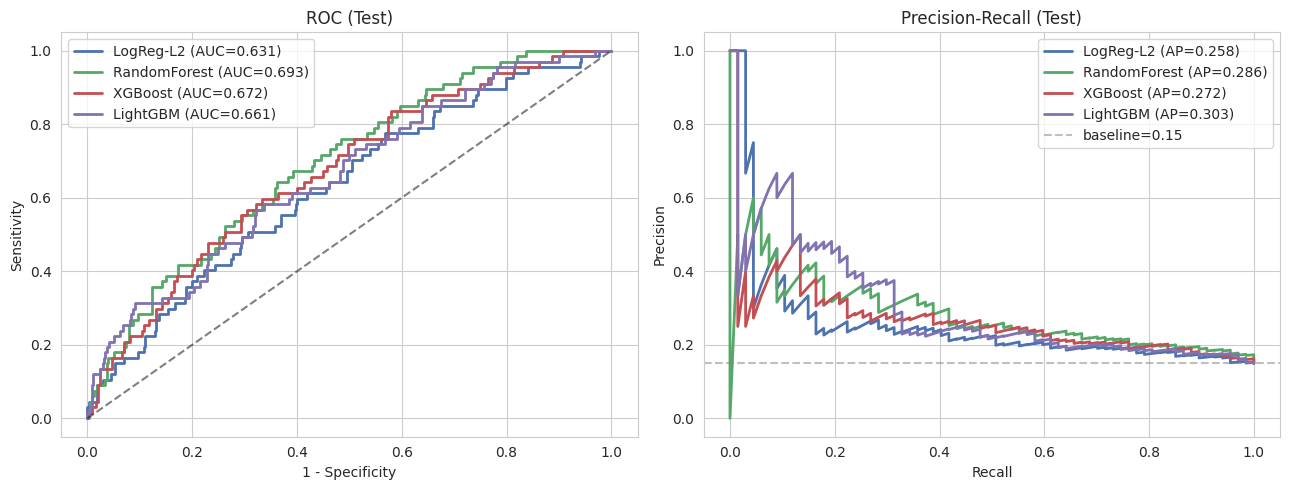

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plot_models = [(n, models[n]) for n in ['LogReg-L2', 'RandomForest', 'XGBoost', 'LightGBM']]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for (name, m), c in zip(plot_models, colors):
    p = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p);  auc = roc_auc_score(y_test, p)
    pre, rec, _ = precision_recall_curve(y_test, p);  ap = average_precision_score(y_test, p)
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=c, lw=2)
    ax[1].plot(rec, pre, label=f'{name} (AP={ap:.3f})', color=c, lw=2)

ax[0].plot([0,1],[0,1],'k--',alpha=.5); ax[0].set_xlabel('1 - Specificity'); ax[0].set_ylabel('Sensitivity'); ax[0].set_title('ROC (Test)'); ax[0].legend()
ax[1].axhline(y_test.mean(),ls='--',c='gray',alpha=.5,label=f'baseline={y_test.mean():.2f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].set_title('Precision-Recall (Test)'); ax[1].legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/roc_pr_curves.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. 最优模型的混淆矩阵 + 阈值统计

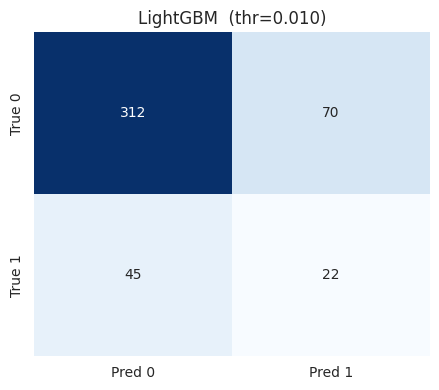

{'threshold': np.float64(0.009777618981559594),
 'sensitivity': np.float64(0.3283582089552239),
 'specificity': np.float64(0.8167539267015707),
 'ppv': np.float64(0.2391304347826087),
 'npv': np.float64(0.8739495798319328),
 'f1': 0.27672955974842767,
 'mcc': 0.12809872138634973}

In [12]:
best_name = best_row['model']
best_model = models[best_name]
p_v  = best_model.predict_proba(X_val)[:, 1]
p_te = best_model.predict_proba(X_test)[:, 1]
thr_y = best_threshold_youden(y_val, p_v)

cm = confusion_matrix(y_test, (p_te >= thr_y).astype(int), labels=[0,1])
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'], ax=ax)
ax.set_title(f'{best_name}  (thr={thr_y:.3f})')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/confusion_matrix_best.png', dpi=150); plt.show()
metrics_at_threshold(y_test, p_te, thr_y)

## 9. 持久化模型 + 超参 + Optuna study

In [13]:
joblib.dump(models['LogReg-L2'],    f'{MODEL_DIR}/lr_l2.joblib')
joblib.dump(models['LogReg-L1'],    f'{MODEL_DIR}/lr_l1.joblib')
joblib.dump(models['RandomForest'], f'{MODEL_DIR}/rf.joblib')
joblib.dump(models['XGBoost'],      f'{MODEL_DIR}/xgb.joblib')
joblib.dump(models['LightGBM'],     f'{MODEL_DIR}/lgb.joblib')
joblib.dump({'name': best_name, 'model': best_model, 'threshold': float(thr_y)},
            f'{MODEL_DIR}/best_model.joblib')

with open(f'{OUT_DIR}/best_params.json', 'w') as f:
    json.dump({'xgb': study_xgb.best_params, 'lgb': study_lgb.best_params,
               'best_model': best_name, 'threshold_youden': float(thr_y)},
              f, indent=2)

print('模型与超参已保存:', sorted(os.listdir(MODEL_DIR)))
print('结果:', sorted(os.listdir(OUT_DIR)))

模型与超参已保存: ['best_model.joblib', 'lgb.joblib', 'lr_l1.joblib', 'lr_l2.joblib', 'rf.joblib', 'xgb.joblib']
结果: ['best_params.json', 'confusion_matrix_best.png', 'metrics_table.csv', 'roc_pr_curves.png']
